In [1]:
!pip install pandas numpy scikit-learn matplotlib

In [6]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [7]:
# Load dataset
df = pd.read_csv("/content/StudentsPerformance.csv")  # Ensure the path is correct
print(df.head())

   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


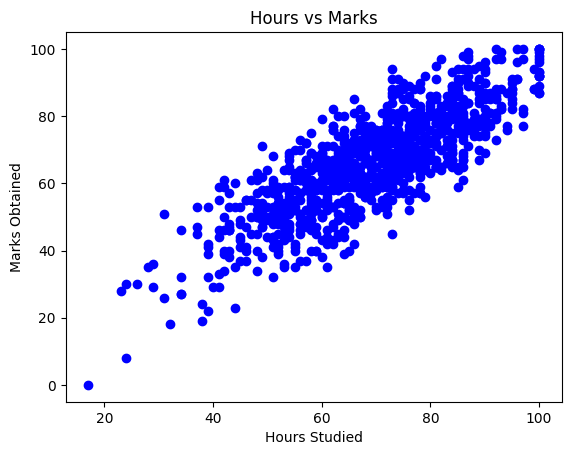

In [11]:
# Data Visualization
# Assuming the column for hours studied is named 'Hours Studied' or 'studytime'
# Replace 'Hours Studied' or 'studytime' with the actual column name if different
# Check the actual column names in your dataframe using df.columns
print(df.columns)  # Print the columns to find the correct name
# Replace 'actual_hours_studied_column' and 'actual_scores_column' with the correct column names
plt.scatter(df['reading score'], df['math score'], color='blue')
plt.title('Hours vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Obtained')
plt.show()

In [14]:
# Prepare Data
X = df[['reading score']]  # Independent variable (Study Hours)
y = df['math score']   # Dependent variable (Scores)

In [15]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [16]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [17]:
# Predict the scores for test data
y_pred = model.predict(X_test)

In [18]:
# Create a DataFrame for actual vs predicted values
df_results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print("\nActual vs Predicted:")
print(df_results)


Actual vs Predicted:
     Actual  Predicted
993      62  68.422846
859      87  69.284170
298      40  46.028419
553      77  59.809605
672      69  73.590791
..      ...        ...
679      63  58.948281
722      74  83.926680
215      84  77.897411
653      65  66.700198
150      62  64.116225

[200 rows x 2 columns]


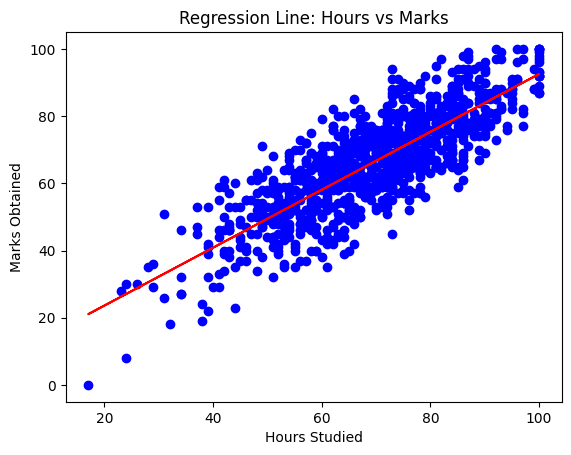

In [19]:
# Plotting the regression line
plt.scatter(X, y, color='blue')
plt.plot(X, model.predict(X), color='red')
plt.title('Regression Line: Hours vs Marks')
plt.xlabel('Hours Studied')
plt.ylabel('Marks Obtained')
plt.show()

In [20]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"\nMean Squared Error: {mse:.2f}")


Mean Squared Error: 86.02


In [21]:
# Predict a custom value (example: 9.25 hours)
hours = 9.25
predicted_score = model.predict([[hours]])
print(f"\nFor {hours} hours of study, the predicted score is: {predicted_score[0]:.2f}")


For 9.25 hours of study, the predicted score is: 14.37


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
